<a href="https://colab.research.google.com/github/Raju-mia-RK/Raju/blob/colab_work/cancer_detction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
dat=pd.read_csv('/content/drive/MyDrive/datasets/Breast_Cancer_Wisconsin_Dataset.csv')



In [35]:
dat.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [36]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [37]:
dat.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [38]:
df=dat.dropna()

In [39]:
dat.shape

(569, 33)

In [40]:
dat.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(
    accuracy_score,confusion_matrix,classification_report,
    precision_score,recall_score,f1_score,
    roc_curve,roc_auc_score,auc
)

In [42]:
dat['diagnosis']=dat['diagnosis'].map({'M':1,'B':0})

In [43]:
dat.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [44]:
numerical_feature=[
'radius_mean',
'perimeter_mean',
'area_mean',
'radius_worst',
'perimeter_worst',
'area_worst',
'concavity_mean',
'concave points_mean',
'concavity_worst',
'concave points_worst',
'compactness_mean',
'compactness_worst'
]

In [45]:
X=dat[numerical_feature]
Y=dat['diagnosis']

In [46]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42,stratify=Y
)


In [57]:
my_model=DecisionTreeClassifier(
    max_depth=2,random_state=42
)
my_model.fit(X_train,Y_train)
prediction=my_model.predict(X_test)
accuracy=accuracy_score(Y_test,prediction)
precison=precision_score(Y_test,prediction)
recall=recall_score(Y_test,prediction)
f1=f1_score(Y_test,prediction)

print(f'Accuracy: {accuracy:.1%}')
print(f'Precision: {precison:.1%}')
print(f'Recall: {recall:.1%}')
print(f'F1 Score: {f1:.1%}' )

Accuracy: 93.0%
Precision: 94.7%
Recall: 85.7%
F1 Score: 90.0%


[[70  2]
 [ 5 37]]
Correct:107
Wrong: 7


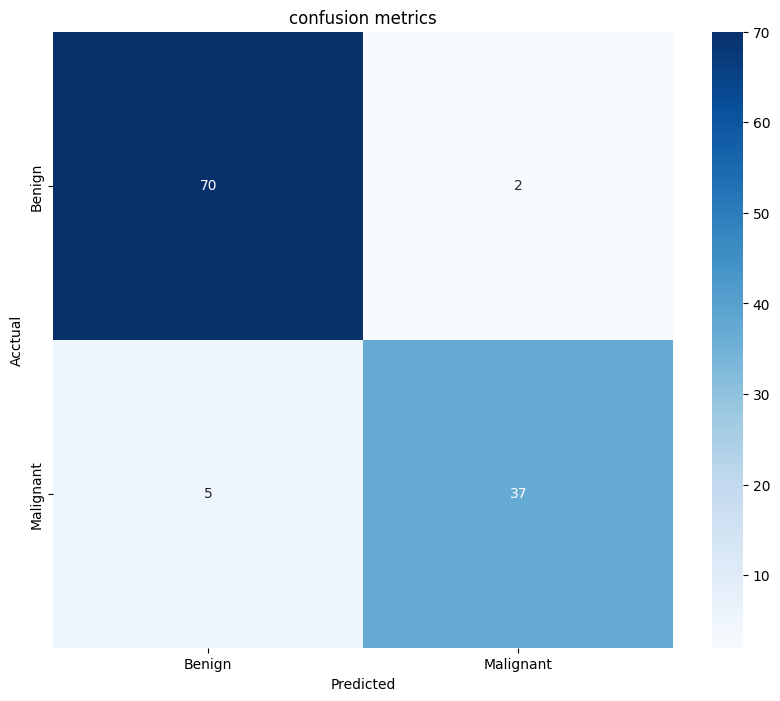

In [50]:
cm=confusion_matrix(Y_test,prediction)
print(cm)
print(f'Correct:{cm[0,0]+cm[1,1]}')
print(f'Wrong: {cm[1,0]+cm[0,1]}')
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='g',cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant']
            )
plt.title('confusion metrics')
plt.xlabel('Predicted')
plt.ylabel('Acctual')
plt.show()

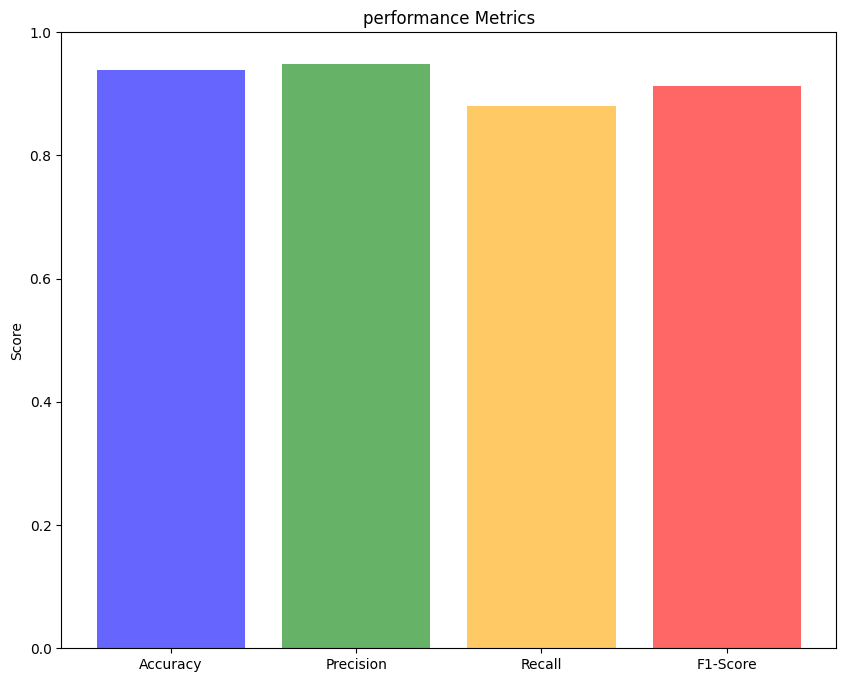

In [54]:
metrics=['Accuracy','Precision','Recall','F1-Score']
value=[accuracy,precison,recall,f1]
plt.figure(figsize=(10,8))
plt.bar(metrics,value,color=['blue','green','orange','red'],alpha=0.6)
plt.ylim(0,1)
plt.title('performance Metrics')
plt.ylabel('Score')
plt.show()

Max Depth=2

Accuracy: 93.0%
Precision: 94.7%
Recall: 85.7%
F1 Score: 90.0%


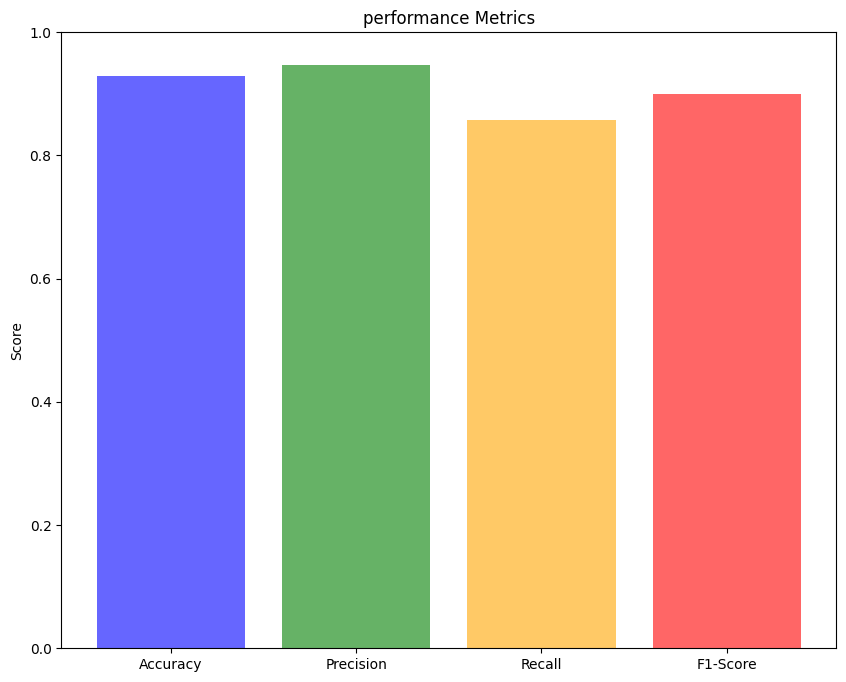

In [59]:
my_model1=DecisionTreeClassifier(
    max_depth=2,random_state=42
)
my_model1.fit(X_train,Y_train)
prediction1=my_model1.predict(X_test)
accuracy1=accuracy_score(Y_test,prediction)
precison1=precision_score(Y_test,prediction)
recall1=recall_score(Y_test,prediction)
f11=f1_score(Y_test,prediction)

print(f'Accuracy: {accuracy1:.1%}')
print(f'Precision: {precison1:.1%}')
print(f'Recall: {recall1:.1%}')
print(f'F1 Score: {f11:.1%}' )
metrics=['Accuracy','Precision','Recall','F1-Score']
value=[accuracy1,precison1,recall1,f11]
plt.figure(figsize=(10,8))
plt.bar(metrics,value,color=['blue','green','orange','red'],alpha=0.6)
plt.ylim(0,1)
plt.title('performance Metrics')
plt.ylabel('Score')
plt.show()

Accuracy: 93.0%
Precision: 94.7%
Recall: 85.7%
F1 Score: 90.0%


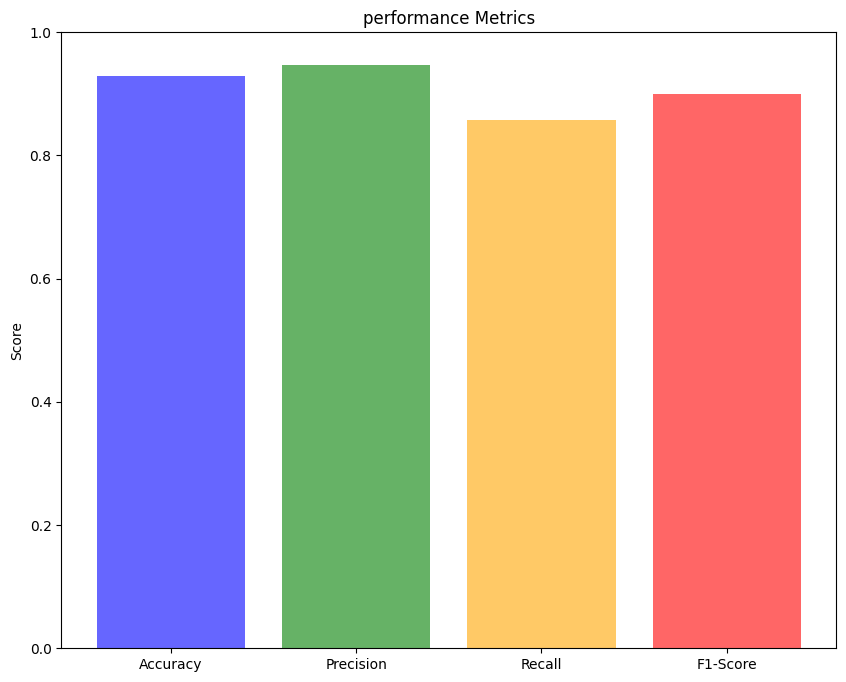

In [60]:
my_model2=DecisionTreeClassifier(
    max_depth=3,random_state=42
)
my_model2.fit(X_train,Y_train)
prediction2=my_model2.predict(X_test)
accuracy2=accuracy_score(Y_test,prediction)
precison2=precision_score(Y_test,prediction)
recall2=recall_score(Y_test,prediction)
f12=f1_score(Y_test,prediction)

print(f'Accuracy: {accuracy2:.1%}')
print(f'Precision: {precison2:.1%}')
print(f'Recall: {recall2:.1%}')
print(f'F1 Score: {f12:.1%}' )
metrics=['Accuracy','Precision','Recall','F1-Score']
value=[accuracy2,precison2,recall2,f12]
plt.figure(figsize=(10,8))
plt.bar(metrics,value,color=['blue','green','orange','red'],alpha=0.6)
plt.ylim(0,1)
plt.title('performance Metrics')
plt.ylabel('Score')
plt.show()

Accuracy: 88.6%
Precision: 93.9%
Recall: 73.8%
F1 Score: 82.7%


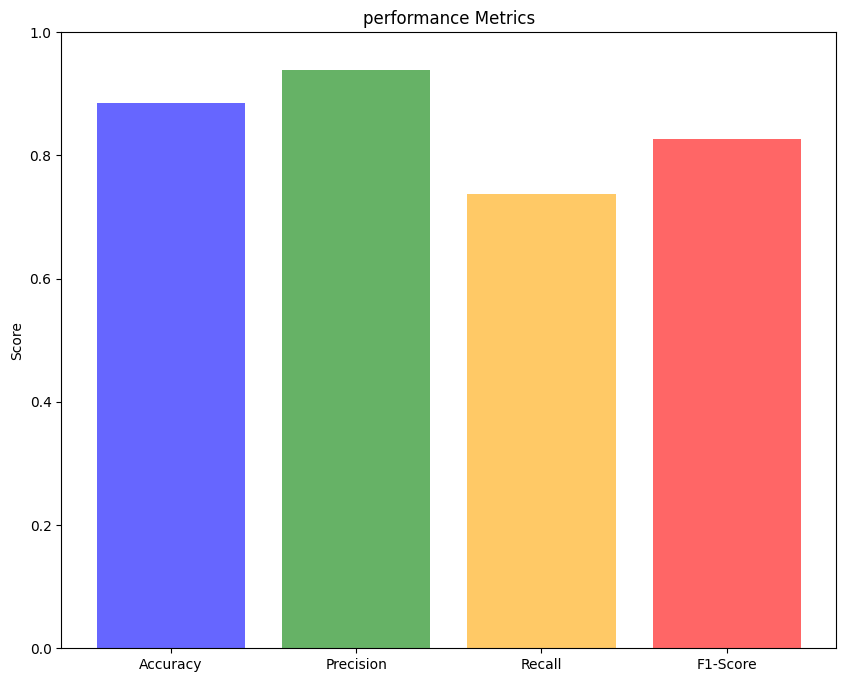

In [62]:
my_model3=DecisionTreeClassifier(
    max_depth=4,random_state=42
)
my_model3.fit(X_train,Y_train)
prediction3=my_model3.predict(X_test)
accuracy3=accuracy_score(Y_test,prediction3)
precision3=precision_score(Y_test,prediction3)
recall3=recall_score(Y_test,prediction3)
f13=f1_score(Y_test,prediction3)
print(f'Accuracy: {accuracy3:.1%}')
print(f'Precision: {precision3:.1%}')
print(f'Recall: {recall3:.1%}')
print(f'F1 Score: {f13:.1%}' )

plt.figure(figsize=(10,8))
metrics=['Accuracy','Precision','Recall','F1-Score']
value=[accuracy3,precision3,recall3,f13]
plt.bar(metrics,value,color=['blue','green','orange','red'],alpha=0.6)
plt.ylim(0,1)
plt.title('performance Metrics')
plt.ylabel('Score')
plt.show()

Accuracy: 88.6%
Precision: 93.9%
Recall: 73.8%
F1 Score: 82.7%


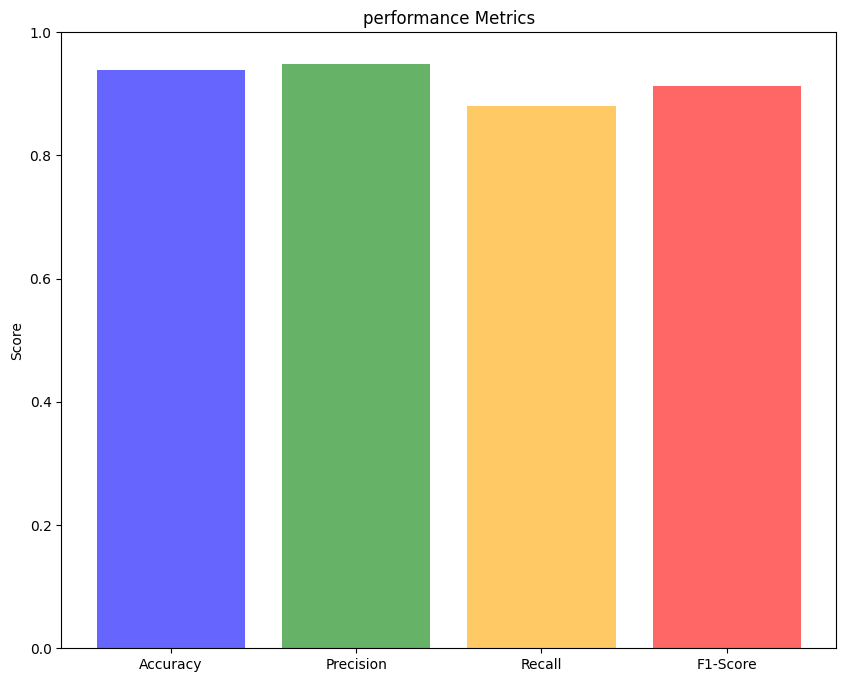

In [63]:
my_model4=DecisionTreeClassifier(
    max_depth=5,random_state=42
)
my_model4.fit(X_train,Y_train)
prediction4=my_model4.predict(X_test)
accuracy4=accuracy_score(Y_test,prediction4)
precision4=precision_score(Y_test,prediction4)
recall4=recall_score(Y_test,prediction4)
f14=f1_score(Y_test,prediction4)
print(f'Accuracy: {accuracy3:.1%}')
print(f'Precision: {precision3:.1%}')
print(f'Recall: {recall3:.1%}')
print(f'F1 Score: {f13:.1%}' )

plt.figure(figsize=(10,8))
metrics=['Accuracy','Precision','Recall','F1-Score']
value=[accuracy4,precision4,recall4,f14]
plt.bar(metrics,value,color=['blue','green','orange','red'],alpha=0.6)
plt.ylim(0,1)
plt.title('performance Metrics')
plt.ylabel('Score')
plt.show()

check new patient

In [64]:
dat.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [72]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

In [73]:
numerical_feature

['radius_mean',
 'perimeter_mean',
 'area_mean',
 'radius_worst',
 'perimeter_worst',
 'area_worst',
 'concavity_mean',
 'concave points_mean',
 'concavity_worst',
 'concave points_worst',
 'compactness_mean',
 'compactness_worst']

In [75]:
new_patient=[[18.5,120.0,1000.0,25.0,165.0,1800.0,0.32,0.18,0.55,0.25,0.28,0.45]]
new_patient_scaled=scaler.fit_transform(new_patient)
prediction=my_model.predict(new_patient_scaled)
if(prediction[0]==1):
  print("Cancer")
else:
  print("No Cancer")


No Cancer


In [76]:
new_patient2 = [[
    18.5,
    120.0,
    1000.0,
    25.0,
    165.0,
    1800.0,
    0.32,
    0.18,
    0.55,
    0.25,
    0.28,
    0.45
]]
new_patient_scaled2=scaler.fit_transform(new_patient2)
prediction2=my_model.predict(new_patient_scaled2)
if(prediction2[0]==1):
  print("Cancer")
else:
  print("No Cancer")

No Cancer
